In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [51]:
df = pd.read_csv(r"/content/heart.csv")

In [52]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA

In [53]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [55]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [56]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

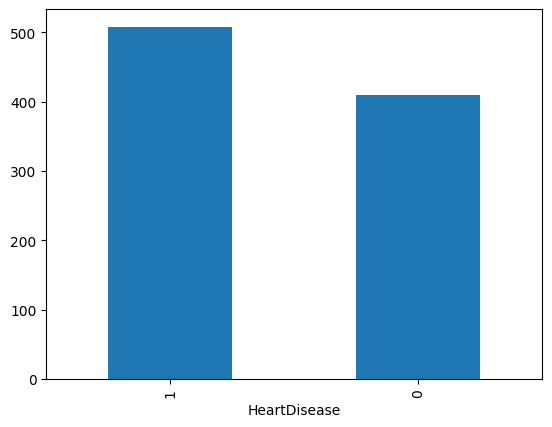

In [57]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [58]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


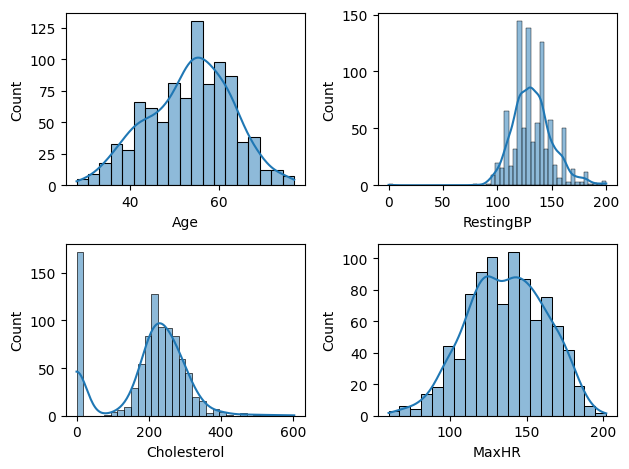

In [59]:
def plotting(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde = True)
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

plt.tight_layout()

In [60]:
df['Cholesterol'].value_counts().head()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9


In [61]:
ch_mean = df.loc[df['Cholesterol']!=0, 'Cholesterol'].mean()

In [62]:
ch_mean

np.float64(244.6353887399464)

In [63]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [64]:
resting_bp_mean = df.loc[df['RestingBP']!=0, 'RestingBP'].mean()

df['RestingBP'] = df['RestingBP'].replace(0,resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

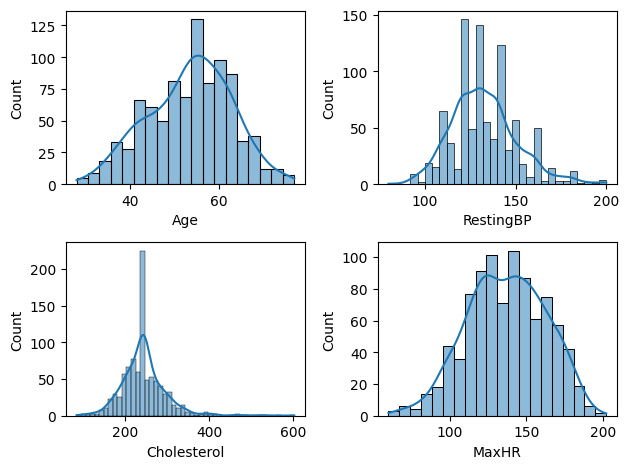

In [65]:
def plotting(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde = True)
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

plt.tight_layout()

In [66]:
df['ChestPainType'].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


<Axes: xlabel='Sex', ylabel='count'>

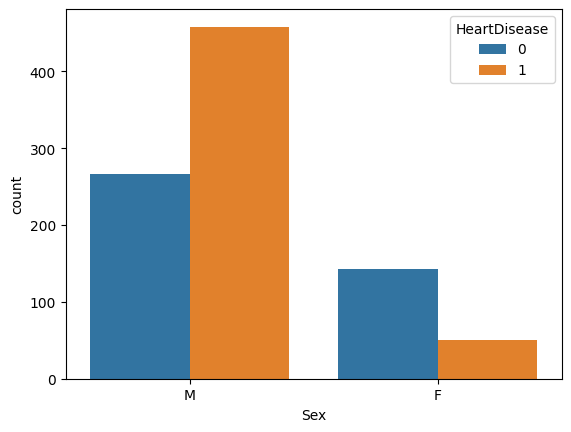

In [67]:
sns.countplot(x=df['Sex'], hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

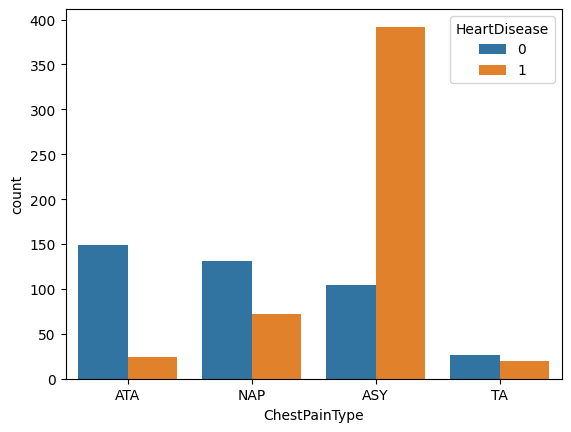

In [68]:
sns.countplot(x=df['ChestPainType'], hue = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

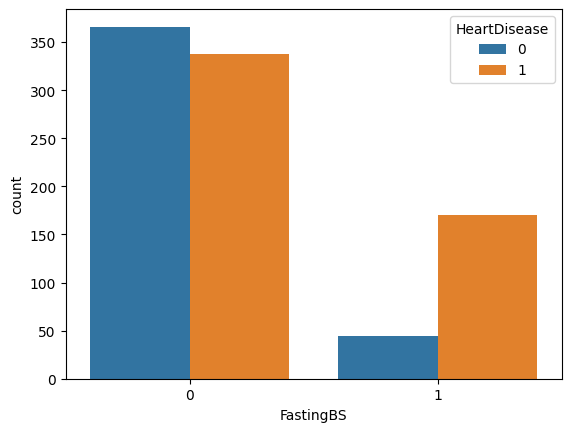

In [69]:
sns.countplot(x=df['FastingBS'], hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

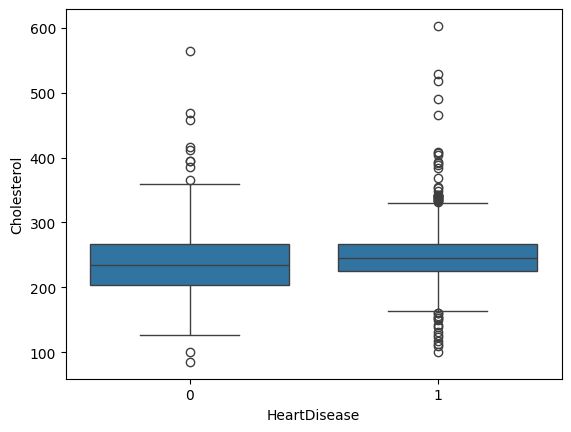

In [70]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

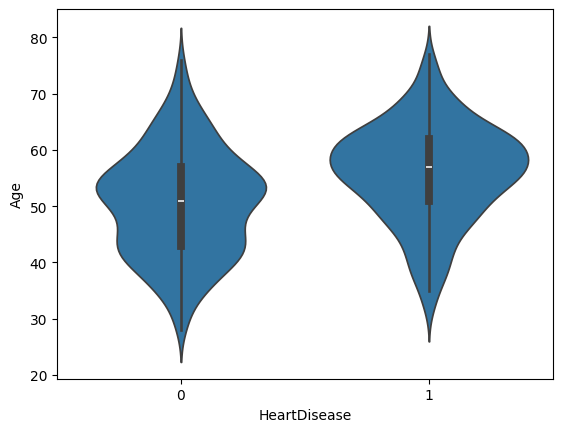

In [71]:
sns.violinplot(x='HeartDisease', y = 'Age', data = df)

<Axes: >

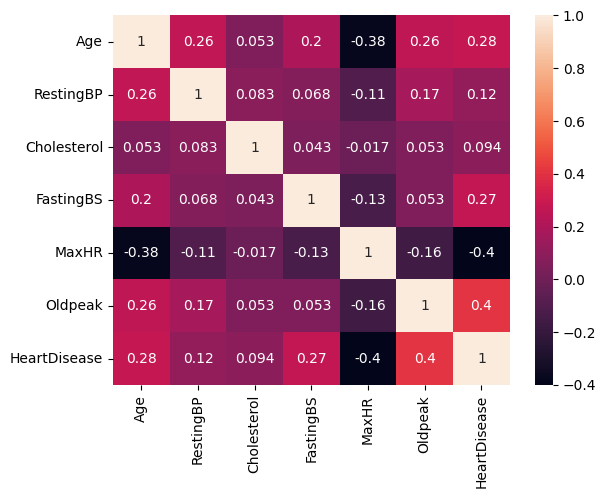

In [72]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data preprocessing and cleaning

In [73]:
df_encode = pd.get_dummies(df, drop_first = True)

In [74]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [75]:
df_encode=df_encode.astype(int)

In [76]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [77]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scalar = StandardScaler()
df_encode[numerical_cols] = scalar.fit_transform(df_encode[numerical_cols])
df_encode.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [78]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

## Feature Extraction

In [79]:
from scipy.stats import pearsonr

# list of features to check against target
selected_features =[
    'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
    'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
    'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
    'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'
]

correlations = {
    feature: pearsonr(df_encode[feature], df_encode['HeartDisease'])[0]
    for feature in selected_features
}

correlations_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlations_df.sort_values (by = 'Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
13,ST_Slope_Flat,0.554134
12,ExerciseAngina_Y,0.494282
5,Oldpeak,0.392385
6,Sex_M,0.305445
0,Age,0.282039
3,FastingBS,0.267291
1,RestingBP,0.117909
11,RestingECG_ST,0.102527
2,Cholesterol,0.092586
9,ChestPainType_TA,-0.054790


In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [81]:
X = df_encode.drop('HeartDisease', axis=1)
y = df_encode['HeartDisease']

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [83]:
scaler = StandardScaler()

In [84]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [85]:
models = {

          "Logistic Regression": LogisticRegression(),
          "Naive Bayes": GaussianNB(),
          "Decision Tree": DecisionTreeClassifier(),
          "KNN": KNeighborsClassifier(),
          "SVM": SVC()
}

In [86]:
result = []

In [87]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        'Model Name': name,
        'Accuracy': round(accuracy,4),
        'F1 Score': round(f1, 4)
    })

In [88]:
result

[{'Model Name': 'Logistic Regression', 'Accuracy': 0.8696, 'F1 Score': 0.8857},
 {'Model Name': 'Naive Bayes', 'Accuracy': 0.8533, 'F1 Score': 0.8683},
 {'Model Name': 'Decision Tree', 'Accuracy': 0.7772, 'F1 Score': 0.8},
 {'Model Name': 'KNN', 'Accuracy': 0.8641, 'F1 Score': 0.8815},
 {'Model Name': 'SVM', 'Accuracy': 0.8478, 'F1 Score': 0.8679}]

In [90]:
import joblib
joblib.dump(models['KNN'], 'KNN_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']